<a href="https://colab.research.google.com/github/ulinnuhagantengbgt-cmyk/Tugas-Data-Infrastruktur/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import os

print("Library berhasil diimport")

Library berhasil diimport


In [3]:
from google.colab import files

uploaded = files.upload()


Saving Sample - Superstore.csv to Sample - Superstore.csv


In [4]:
df_raw = pd.read_csv(
    "Sample - Superstore.csv",
    encoding="latin1"
)

print("Dataset berhasil dibaca")

Dataset berhasil dibaca


In [5]:
print(df_raw.head())


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [6]:
print(df_raw.shape)

(9994, 21)


In [7]:
print(df_raw.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/clean", exist_ok=True)
os.makedirs("data/curated", exist_ok=True)

print("Folder data lake berhasil dibuat")

Folder data lake berhasil dibuat


In [9]:
df_raw.to_csv(
    "data/raw/superstore_raw.csv",
    index=False
)

print("Data raw berhasil disimpan")

Data raw berhasil disimpan


In [10]:
df = pd.read_csv(
    "data/raw/superstore_raw.csv"
)

print("Data raw berhasil dibaca kembali")

Data raw berhasil dibaca kembali


In [11]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [12]:
print(df.duplicated().sum())

0


In [13]:
df = df.dropna(
    subset=["Sales", "Order Date"]
)

# Menghapus data duplikat
df = df.drop_duplicates()

print("Cleaning data selesai")

Cleaning data selesai


In [14]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"]
)

df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

print("Transformasi tanggal berhasil")

Transformasi tanggal berhasil


In [15]:
df["Profit_Margin"] = (
    df["Profit"] / df["Sales"]
)

print("Kolom Profit_Margin berhasil dibuat")

Kolom Profit_Margin berhasil dibuat


In [16]:
df.to_csv(
    "data/clean/superstore_clean.csv",
    index=False
)

print("Clean data berhasil disimpan")


Clean data berhasil disimpan


In [20]:
df_curated = df[[
    "Order ID",
    "Order Date",
    "Year",
    "Month",
    "Category",
    "Sub-Category",
    "Region",
    "Sales",
    "Profit",
    "Profit_Margin"
]]

In [21]:
df_curated.to_csv(
    "data/curated/superstore_curated.csv",
    index=False
)

print("Curated dataset berhasil disimpan")

Curated dataset berhasil disimpan


In [22]:
print(df_curated.info())

print(df_curated.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   object        
 1   Order Date     9994 non-null   datetime64[ns]
 2   Year           9994 non-null   int32         
 3   Month          9994 non-null   int32         
 4   Category       9994 non-null   object        
 5   Sub-Category   9994 non-null   object        
 6   Region         9994 non-null   object        
 7   Sales          9994 non-null   float64       
 8   Profit         9994 non-null   float64       
 9   Profit_Margin  9994 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int32(2), object(4)
memory usage: 702.8+ KB
None
         Order ID Order Date  Year  Month         Category Sub-Category  \
0  CA-2016-152156 2016-11-08  2016     11        Furniture    Bookcases   
1  CA-2016-152156 2016-11-08  2016     11  

In [23]:
sales_category = df_curated.groupby(
    "Category"
)["Sales"].sum()

print(sales_category)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


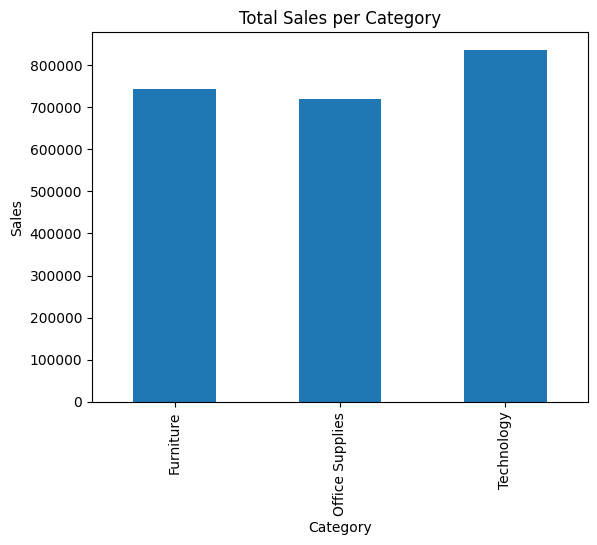

In [24]:
import matplotlib.pyplot as plt

sales_category.plot(
    kind="bar"
)

plt.title("Total Sales per Category")

plt.xlabel("Category")

plt.ylabel("Sales")

plt.show()

# Arsitektur Data dan Komponen Data Analytics

## Arsitektur Data Analytics

Arsitektur data analytics merupakan struktur atau alur kerja yang digunakan untuk mengelola data mulai dari data mentah hingga menjadi informasi yang siap digunakan. Dalam dunia digital saat ini, data menjadi salah satu hal penting karena hampir semua aktivitas menghasilkan data yang dapat dimanfaatkan untuk membantu pengambilan keputusan.

Arsitektur data analytics membantu proses pengelolaan data menjadi lebih terstruktur dan terorganisir. Dengan adanya arsitektur data yang baik, data dapat diproses dengan lebih cepat, akurat, dan mudah dianalisis.

Secara umum arsitektur data analytics terdiri dari beberapa tahapan yaitu data source, data ingestion, data processing, data storage, serta analytics dan visualization.

## Data Source

Data source merupakan sumber data mentah yang digunakan dalam proses analytics. Data dapat berasal dari berbagai sumber seperti file CSV, database, website, API, media sosial, maupun aplikasi tertentu.

Pada tahap ini data biasanya masih belum terstruktur dengan baik sehingga perlu dilakukan pengolahan lebih lanjut sebelum digunakan untuk analisis. Kualitas data source sangat mempengaruhi hasil analisis yang akan dilakukan.

## Data Ingestion

Data ingestion merupakan proses pengambilan dan pengiriman data dari sumber data menuju sistem pengolahan data. Tahap ini penting karena menjadi langkah awal dalam proses data analytics.

Proses ingestion dapat dilakukan secara manual maupun otomatis menggunakan tools tertentu. Dalam praktik ini proses ingestion dilakukan menggunakan Python untuk membaca dataset yang telah diupload ke Google Colab.

Tujuan dari data ingestion yaitu agar data dari berbagai sumber dapat dikumpulkan dan diproses dalam satu sistem.

## Data Processing

Data processing merupakan tahap pengolahan data agar data menjadi lebih bersih dan siap digunakan untuk analisis. Pada tahap ini dilakukan beberapa proses seperti cleaning data, transformasi data, dan pengecekan kualitas data.

Contoh proses yang dilakukan yaitu menghapus data kosong, menghapus data duplikat, mengubah format tanggal, dan menambahkan kolom baru.

Tahap processing sangat penting karena kualitas data sangat mempengaruhi hasil analisis. Jika data masih banyak kesalahan maka hasil analisis juga menjadi kurang akurat.

## Data Storage

Data storage digunakan untuk menyimpan data hasil pengolahan agar dapat digunakan kembali untuk kebutuhan analisis maupun pelaporan. Penyimpanan data biasanya menggunakan Data Lake atau Data Warehouse.

Dalam praktik ini dibuat beberapa folder penyimpanan yaitu raw, clean, dan curated. Folder raw digunakan untuk menyimpan data mentah, folder clean digunakan untuk menyimpan data yang sudah dibersihkan, sedangkan curated digunakan untuk menyimpan data yang siap dianalisis.

## Analytics dan Visualization

Tahap terakhir yaitu analytics dan visualization. Pada tahap ini data dianalisis untuk menghasilkan informasi yang berguna. Hasil analisis kemudian ditampilkan dalam bentuk tabel, grafik, maupun dashboard agar lebih mudah dipahami.

Visualisasi data membantu pengguna dalam membaca pola data serta membantu proses pengambilan keputusan berdasarkan informasi yang diperoleh.

## Peran Python dalam Data Analytics

Python merupakan salah satu bahasa pemrograman yang banyak digunakan dalam bidang data analytics. Python digunakan untuk membaca data, membersihkan data, melakukan transformasi data, hingga analisis data.

Python banyak digunakan karena mudah dipelajari dan memiliki banyak library pendukung seperti pandas, numpy, dan matplotlib. Selain itu Python juga mampu mengolah data dalam jumlah besar dengan lebih cepat dan efisien.

Dalam praktik ini Python digunakan untuk membaca dataset, melakukan cleaning data, transformasi data, menyimpan data, dan melakukan analisis sederhana.

# Praktik Pengolahan Data

## Import Library

Langkah pertama yaitu mengimport library yang dibutuhkan seperti pandas dan os. Library pandas digunakan untuk membaca dan mengolah data sedangkan os digunakan untuk membuat folder penyimpanan data.

## Upload dan Membaca Dataset

Dataset Superstore diupload terlebih dahulu ke Google Colab kemudian dibaca menggunakan pandas. Setelah dataset berhasil dibaca dilakukan pengecekan isi dataset untuk melihat jumlah data, nama kolom, dan tipe data yang digunakan.

## Membuat Struktur Data Lake

Tahap berikutnya yaitu membuat struktur folder data lake yang terdiri dari folder raw, clean, dan curated. Struktur folder ini membantu proses pengelolaan data agar lebih rapi dan mudah dipahami.

## Cleaning Data

Pada tahap ini dilakukan pengecekan missing value dan data duplikat. Data yang kosong dan duplikat kemudian dihapus agar kualitas data menjadi lebih baik.

Selain itu dilakukan juga transformasi format tanggal dan penambahan kolom baru seperti year, month, dan profit margin untuk membantu proses analisis data.

## Penyimpanan Data

Data hasil cleaning kemudian disimpan ke dalam clean zone. Setelah itu dibuat curated dataset dengan memilih beberapa kolom penting yang akan digunakan untuk analisis data.

## Analisis Data

Tahap terakhir yaitu melakukan analisis sederhana menggunakan data yang sudah diproses. Analisis dilakukan untuk melihat total penjualan berdasarkan kategori produk sehingga dapat diketahui kategori produk dengan penjualan tertinggi.

# Kesimpulan

Berdasarkan praktik yang telah dilakukan dapat disimpulkan bahwa arsitektur data analytics membantu proses pengelolaan data menjadi lebih terstruktur mulai dari pengambilan data, pengolahan data, penyimpanan data, hingga proses analisis data.

Python memiliki peran penting dalam proses data analytics karena dapat digunakan untuk membaca data, membersihkan data, melakukan transformasi data, dan analisis data. Dengan menggunakan Google Colab dan Python, proses pengolahan data menjadi lebih mudah dilakukan dan membantu menghasilkan informasi yang berguna dari data mentah.
